In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('covid_19.csv')
df.head()

,country,continent,population,day,time,Cases,Recovered,Deaths,Tests
0,Saint-Helena,Africa,6115.0,2024-06-30,2024-06-30T16:15:16+00:00,2166,2.0,NaN,NaN
1,Falkland-Islands,South-America,3539.0,2024-06-30,2024-06-30T16:15:16+00:00,1930,1930.0,NaN,8632.0
2,Montserrat,North-America,4965.0,2024-06-30,2024-06-30T16:15:16+00:00,1403,1376.0,8.0,17762.0
3,Diamond-Princess,NaN,NaN,2024-06-30,2024-06-30T16:15:16+00:00,712,699.0,13.0,NaN
4,Vatican-City,Europe,799.0,2024-06-30,2024-06-30T16:15:16+00:00,29,29.0,NaN,NaN


In [4]:
df.shape

(238, 9)

In [5]:
df.dtypes

country        object
continent      object
population    float64
day            object
time           object
Cases           int64
Recovered     float64
Deaths        float64
Tests         float64
dtype: object

In [7]:
missing_count = df.isnull().sum()
missing_count

country        0
continent      2
population     9
day            0
time           0
Cases          0
Recovered     48
Deaths         5
Tests         25
dtype: int64

In [8]:
missing_pct = (missing_count / len(df) * 100).round(1)
missing_pct

country        0.0
continent      0.8
population     3.8
day            0.0
time           0.0
Cases          0.0
Recovered     20.2
Deaths         2.1
Tests         10.5
dtype: float64

In [9]:
missing_summary = pd.DataFrame({
    'missing_count' : missing_count,
    'missing_pct' : missing_pct
})
missing_summary

,missing_count,missing_pct
country,0,0.0
continent,2,0.8
population,9,3.8
day,0,0.0
time,0,0.0
Cases,0,0.0
Recovered,48,20.2
Deaths,5,2.1
Tests,25,10.5


In [ ]:
missing_summary = missing_summary[missing_summary['missing_count'] > 0] 
missing_summary = missing_summary.sort_values('missing_count', ascending=False)
print("Missing values summary:")
print(missing_summary)
print()

Missing values summary:
            missing_count  missing_pct
Recovered              48         20.2
Tests                  25         10.5
population              9          3.8
Deaths                  5          2.1
continent               2          0.8



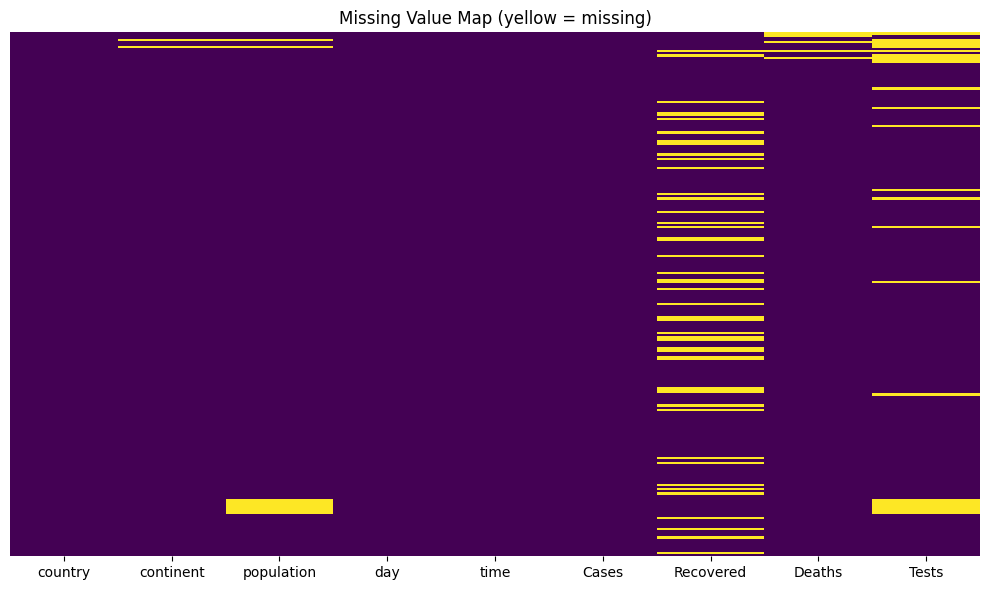

In [14]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Map (yellow = missing)')
plt.tight_layout()
plt.show()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
print("Mean Recovered (NaNs auto-skipped):", df['Recovered'].mean().round(1))
print("Count of non-missing Recovered values used:", df['Recovered'].count())

Mean Recovered (NaNs auto-skipped): 10062139.9
Count of non-missing Recovered values used: 190


In [17]:
print(df[['country', 'Recovered']].sort_values('Recovered', ascending=False).head(10))

           country    Recovered
218            All  675619811.0
214         Europe  248754104.0
213           Asia  205673091.0
212  North-America  127665129.0
219            USA  109814428.0
215  South-America   66683585.0
221         France   39970918.0
222        Germany   38240600.0
223         Brazil   36249161.0
224        S-Korea   34535939.0


In [22]:
print(df[df['country'].isin(['All', 'Europe', 'Asia', 'North-America', 'South-America', 'Africa', 'Oceania'])])

           country      continent  population         day  \
212  North-America  North-America         NaN  2024-06-30   
213           Asia           Asia         NaN  2024-06-30   
214         Europe         Europe         NaN  2024-06-30   
215  South-America  South-America         NaN  2024-06-30   
216        Oceania        Oceania         NaN  2024-06-30   
217         Africa         Africa         NaN  2024-06-30   
218            All            All         NaN  2024-06-30   

                          time      Cases    Recovered     Deaths  Tests  
212  2024-06-30T16:15:10+00:00  131889132  127665129.0  1695941.0    NaN  
213  2024-06-30T16:15:10+00:00  221500265  205673091.0  1553662.0    NaN  
214  2024-06-30T16:15:10+00:00  253406198  248754104.0  2101824.0    NaN  
215  2024-06-30T16:15:10+00:00   70200879   66683585.0  1367332.0    NaN  
216  2024-06-30T16:15:10+00:00   14895771   14752388.0    33015.0    NaN  
217  2024-06-30T16:15:10+00:00   12860924   12090808.0   2588

In [19]:
fake_rows = ['All', 'Europe', 'Asia', 'North-America', 'South-America', 'Africa', 'Oceania']
df_clean = df[~df['country'].isin(fake_rows)]
print(df_clean.shape)

(231, 9)


In [20]:
print("Mean Recovered (clean):", df_clean['Recovered'].mean().round(1))
print("Median Recovered (clean):", df_clean['Recovered'].median().round(1))

Mean Recovered (clean): 3063211.3
Median Recovered (clean): 187078.0


In [21]:
print(df_clean.duplicated().sum())

0


In [24]:
# Step 3 — Univariate analysis

In [25]:
print(df_clean['Cases'].describe())

count    2.310000e+02
mean     3.050883e+06
std      1.002125e+07
min      9.000000e+00
25%      2.636600e+04
50%      2.068970e+05
75%      1.348198e+06
max      1.118201e+08
Name: Cases, dtype: float64


In [26]:
print(df_clean)

              country      continent   population         day  \
0        Saint-Helena         Africa       6115.0  2024-06-30   
1    Falkland-Islands  South-America       3539.0  2024-06-30   
2          Montserrat  North-America       4965.0  2024-06-30   
3    Diamond-Princess            NaN          NaN  2024-06-30   
4        Vatican-City         Europe        799.0  2024-06-30   
..                ...            ...          ...         ...   
233         Argentina  South-America   46010234.0  2024-06-30   
234       Netherlands         Europe   17211447.0  2024-06-30   
235            Mexico  North-America  131562772.0  2024-06-30   
236              Iran           Asia   86022837.0  2024-06-30   
237         Indonesia           Asia  279134505.0  2024-06-30   

                          time     Cases  Recovered    Deaths        Tests  
0    2024-06-30T16:15:16+00:00      2166        2.0       NaN          NaN  
1    2024-06-30T16:15:16+00:00      1930     1930.0       NaN    

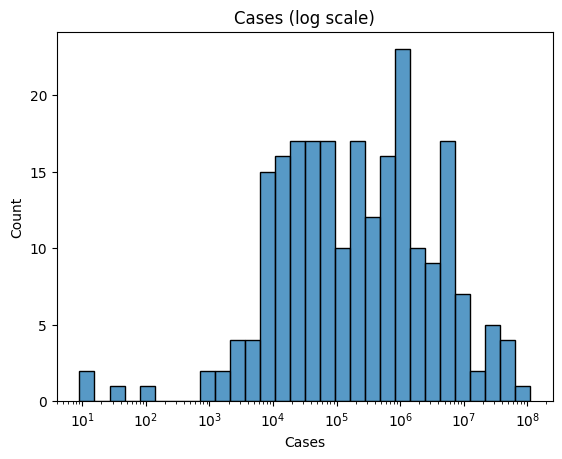

In [27]:
sns.histplot(df_clean['Cases'], bins=30, log_scale=True)
plt.title('Cases (log scale)')
plt.show()

In [28]:
print(df_clean['Deaths'].describe())

count    2.260000e+02
mean     3.102071e+04
std      1.103436e+05
min      1.000000e+00
25%      2.055000e+02
50%      2.204500e+03
75%      1.480600e+04
max      1.219487e+06
Name: Deaths, dtype: float64


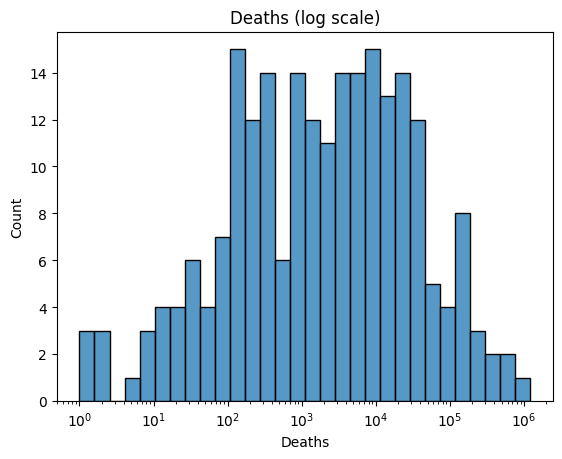

In [29]:
sns.histplot(df_clean['Deaths'].dropna(), bins=30, log_scale=True)
plt.title('Deaths (log scale)')
plt.show()

In [30]:
print(df_clean['population'].describe())

count    2.290000e+02
mean     3.469404e+07
std      1.386374e+08
min      7.990000e+02
25%      4.454310e+05
50%      5.797805e+06
75%      2.210284e+07
max      1.448471e+09
Name: population, dtype: float64


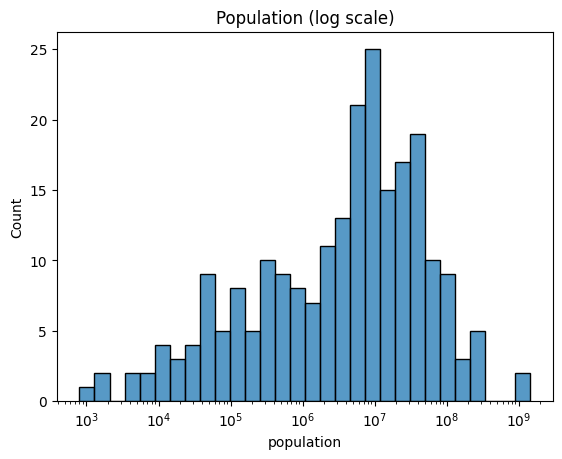

In [31]:
sns.histplot(df_clean['population'].dropna(), bins=30, log_scale=True)
plt.title('Population (log scale)')
plt.show()

In [32]:
print(df_clean['Tests'].describe())

count    2.130000e+02
mean     3.298829e+07
std      1.198779e+08
min      7.850000e+03
25%      3.478150e+05
50%      2.226216e+06
75%      1.346373e+07
max      1.186852e+09
Name: Tests, dtype: float64


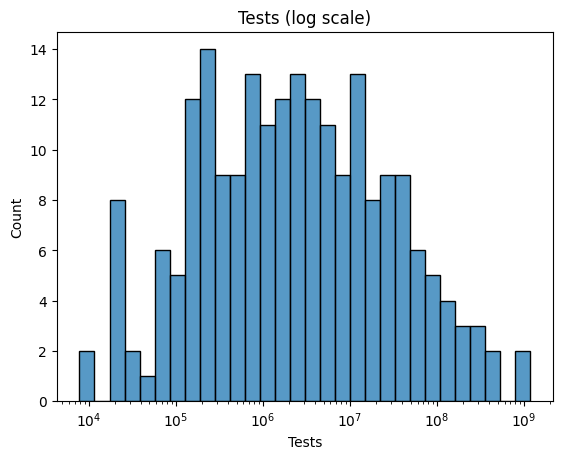

In [33]:
sns.histplot(df_clean['Tests'].dropna(), bins=30, log_scale=True)
plt.title('Tests (log scale)')
plt.show()

In [35]:
print(df_clean[['population', 'Cases', 'Recovered', 'Deaths', 'Tests']].corr())

            population     Cases  Recovered    Deaths     Tests
population    1.000000  0.367741   0.237196  0.404331  0.540603
Cases         0.367741  1.000000   0.999863  0.886136  0.837956
Recovered     0.237196  0.999863   1.000000  0.885424  0.862615
Deaths        0.404331  0.886136   0.885424  1.000000  0.801020
Tests         0.540603  0.837956   0.862615  0.801020  1.000000


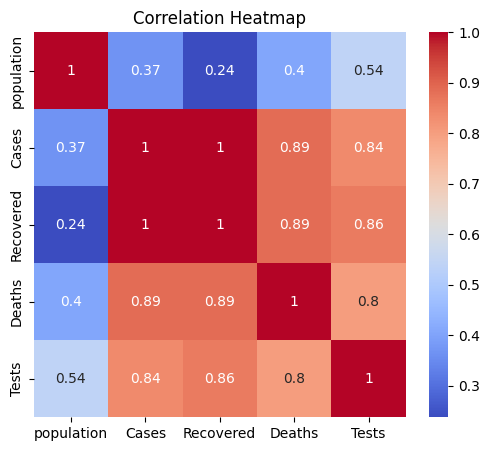

In [36]:
plt.figure(figsize=(6,5))
sns.heatmap(df_clean[['population','Cases','Recovered','Deaths','Tests']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

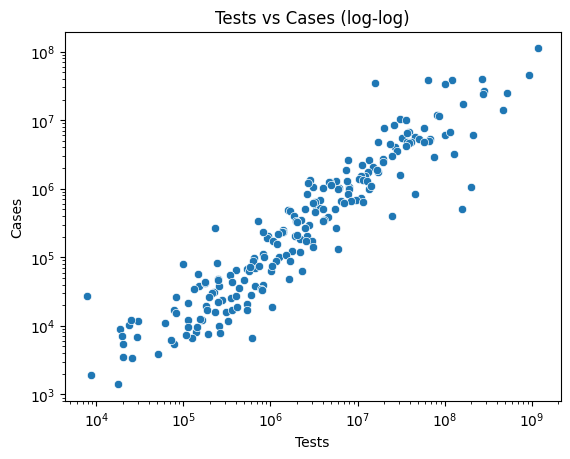

In [ ]:
sns.scatterplot(data=df_clean, x='Tests', y='Cases')
plt.xscale('log')
plt.yscale('log')
plt.title('Tests vs Cases (log-log)')
plt.show()S

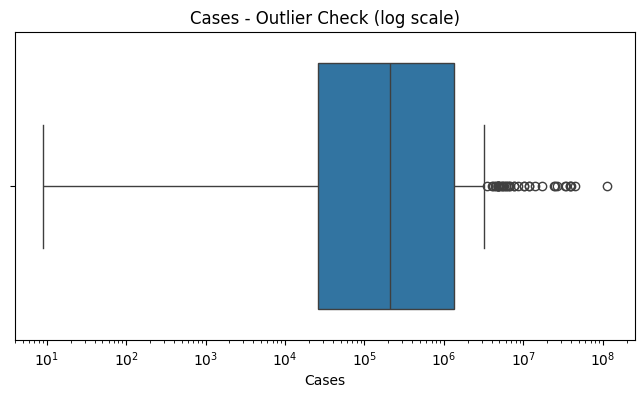

In [38]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean['Cases'])
plt.xscale('log')
plt.title('Cases - Outlier Check (log scale)')
plt.show()

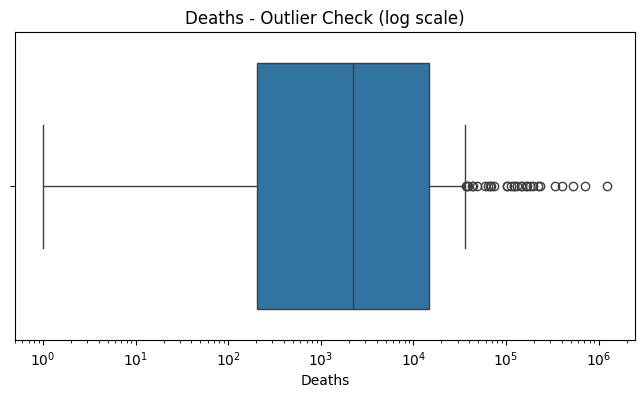

In [39]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean['Deaths'])
plt.xscale('log')
plt.title('Deaths - Outlier Check (log scale)')
plt.show()

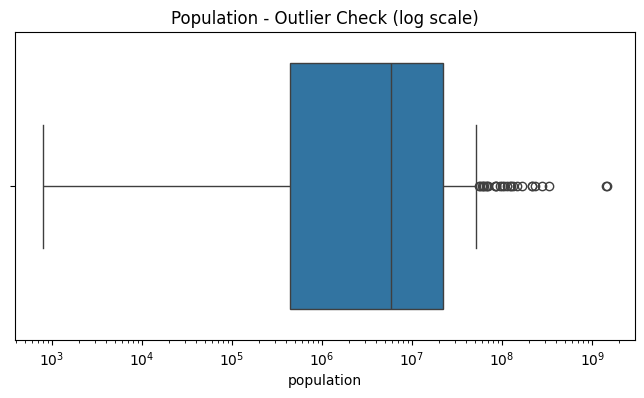

In [40]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean['population'])
plt.xscale('log')
plt.title('Population - Outlier Check (log scale)')
plt.show()

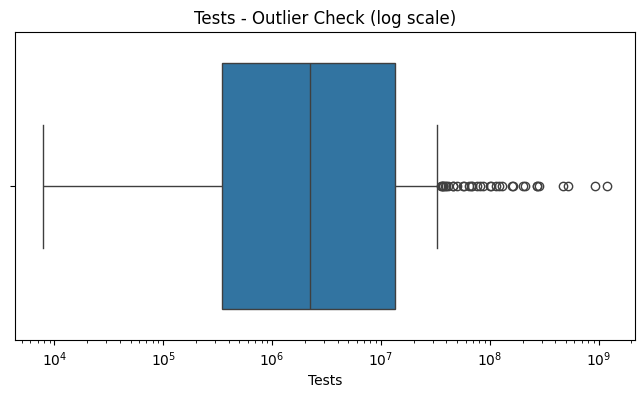

In [41]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean['Tests'])
plt.xscale('log')
plt.title('Tests - Outlier Check (log scale)')
plt.show()

In [ ]:
EDA Summary — COVID-19 Dataset
1. Data: 238 rows → cleaned to 231 real countries (removed 7 aggregate rows: "All" total + 6 continent totals like "Asia", "Europe").
2. Missing values: Kept as NaN, not filled with 0 or average — missing meant "not reported by that country," not actually zero.

Recovered: 20% missing
Tests: 10.5% missing
population, Deaths, continent: small % missing

3. Distributions: Cases, Deaths, population, Tests were all right-skewed (mean much bigger than median), but became normal bell-shaped curves on a log scale.
This means a few large countries (US, India, China) dominate every metric, while most countries cluster in a moderate range.
4. Correlations:

Cases ↔ Recovered: ~1.0 (almost perfectly tied together)
Cases, Deaths, Tests: strongly correlated with each other (0.8–0.89)
population: only weakly correlated with everything (0.24–0.54) — country size alone doesn't strongly predict case/death/test counts

5. Outliers: In every column, the same handful of large countries (US, India, China, Brazil) showed up as outliers in the boxplots.
These are genuine extreme values, not data errors, so they were kept rather than removed.
Key insight: COVID numbers scale with country size, but testing/reporting differences across countries matter just as much
 — that's why population only weakly correlates with Cases (0.37).